In [101]:
####Региональные особенности (1)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

num_entries = 1000
date_range = pd.date_range(start='2022-01-01', end='2022-12-31', periods=num_entries)

data = {
    'Product_Name': np.random.choice(['Milk', 'Bread', 'Eggs', 'Candy', 'Chocolate', 'Butter', 'Cheese', 'Yogurt', 'Juice', 'Cookies'], num_entries),
    'Category': np.random.choice(['Dairy', 'Bakery', 'Confectionery', 'Beverages', 'Snacks'], num_entries),
    'Store_ID': np.random.randint(1, 10, num_entries),
    'Purchase_Date': date_range,
    'Sales_Date': pd.to_datetime(np.random.choice(date_range, num_entries)),
    'Quantity_Purchased': np.random.randint(1, 50, num_entries),
    'Quantity_Sold': np.random.randint(1, 50, num_entries),
    'Purchase_Price': np.round(np.random.uniform(1, 20, num_entries), 2),
    'Selling_Price': np.round(np.random.uniform(2, 30, num_entries), 2),
    'Discount': np.round(np.random.uniform(0, 0.3, num_entries), 2),
    'Stock_Level': np.random.randint(0, 100, num_entries),
    'Demand_Forecast': np.random.randint(1, 100, num_entries),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], num_entries),
    'Competitor_Price': np.round(np.random.uniform(2, 25, num_entries), 2),
    'Marketing_Campaign': np.random.choice([0, 1], num_entries),
    'Seasonality': np.random.choice(['Holiday Season', 'Regular', 'Black Friday', 'Summer Sales'], num_entries),
    'Returns': np.random.randint(0, 5, num_entries),
}

shop_data = pd.DataFrame(data)
shop_data['Revenue'] = shop_data['Selling_Price'] * shop_data['Quantity_Sold'] * (1 - shop_data['Discount'])

shop_data['Sales_Week'] = shop_data['Sales_Date'].dt.to_period('W')
weekly_data = shop_data.groupby(['Sales_Week', 'Product_Name'])['Quantity_Sold'].sum().reset_index()


In [102]:
product_series = weekly_data[weekly_data['Product_Name'] == 'Milk']
product_series.set_index('Sales_Week', inplace=True)
product_series.index = product_series.index.to_timestamp()

In [103]:
sarima_model = SARIMAX(product_series['Quantity_Sold'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 52))
sarima_result = sarima_model.fit()
sarima_forecast = sarima_result.forecast(steps=12)

/Users/dariyakenzhegaliyeva/my_en/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/dariyakenzhegaliyeva/my_en/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/dariyakenzhegaliyeva/my_en/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/dariyakenzhegaliyeva/my_en/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -0.00000D+00    |proj g|=  0.00000D+00

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5      0      1      0     0     0   0.000D+00  -0.000D+00
  F =  -0.0000000000000000     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


/Users/dariyakenzhegaliyeva/my_en/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/dariyakenzhegaliyeva/my_en/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [104]:
X = shop_data[['Quantity_Purchased', 'Discount', 'Stock_Level', 'Competitor_Price', 'Marketing_Campaign']]
y = shop_data['Quantity_Sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

In [106]:
gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)

GradientBoostingRegressor()

In [107]:
gb_predictions = gb_model.predict(X_test)

# Графики
plt.figure(figsize=(16, 8))

<Figure size 1600x800 with 0 Axes>

<Figure size 1600x800 with 0 Axes>

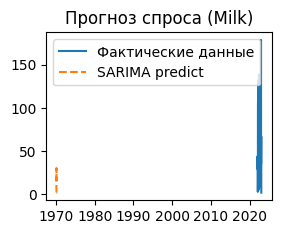

In [108]:
plt.subplot(2, 2, 1)
plt.plot(product_series['Quantity_Sold'], label='Фактические данные')
plt.plot(sarima_forecast, label='SARIMA predict', linestyle='--')
plt.title('Прогноз спроса (Milk)')
plt.legend()

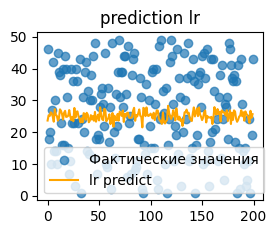

In [109]:
plt.subplot(2, 2, 2)
plt.scatter(range(len(y_test)), y_test, label='Фактические значения', alpha=0.7)
plt.plot(range(len(y_test)), lr_predictions, label='lr predict', color='orange')
plt.title('prediction lr')
plt.legend()

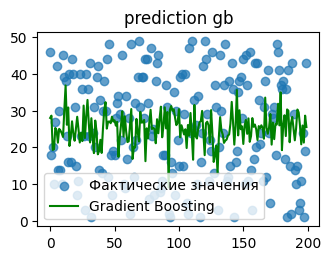

In [110]:
plt.subplot(2, 2, 3)
plt.scatter(range(len(y_test)), y_test, label='Фактические значения', alpha=0.7)
plt.plot(range(len(y_test)), gb_predictions, label='Gradient Boosting', color='green')
plt.title('prediction gb')
plt.legend()

plt.tight_layout()
plt.show()

In [114]:
#### Модель оптимизации закупок (3)

from scipy.optimize import linprog
import numpy as np
import matplotlib.pyplot as plt
import random

products = shop_data['Product_Name'].unique()
num_products = len(products)

avg_demand = shop_data.groupby('Product_Name')['Quantity_Sold'].mean()
avg_stock = shop_data.groupby('Product_Name')['Stock_Level'].mean()
avg_price = shop_data.groupby('Product_Name')['Purchase_Price'].mean()


budget = 5000#бюджет закупки
max_storage = 1000


In [115]:
#линейное программирование
c = avg_price.values# Целевая функция: минимизация стоимости
A_eq = [avg_demand.values]  # Удовлетворение спроса
b_eq = [sum(avg_demand)]  # Общий спрос
A_ub = [avg_price.values, [1] * num_products]  # Ограничения бюджета и склада
b_ub = [budget, max_storage]

In [116]:
result_lp = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, method='highs')
optimal_lp = result_lp.x if result_lp.success else [0] * num_products

In [132]:
#o	KnapSack Problem (задача рюкзака): 
values = avg_demand.values  #(спрос)
weights = avg_price.values  #(цена закупки)
capacity = budget

dp = np.zeros((num_products + 1, capacity + 1))
for i in range(1, num_products + 1):
    for w in range(capacity + 1):
        if weights[i - 1] <= w:
            dp[i][w] = max(dp[i - 1][w], dp[i - 1][w - int(weights[i - 1])] + values[i - 1])
        else:
            dp[i][w] = dp[i - 1][w]

optimal_knapsack = []
w = capacity
for i in range(num_products, 0, -1):
    if dp[i][w] != dp[i - 1][w]:
        optimal_knapsack.append(i - 1)
        w -= int(weights[i - 1])

optimal_knapsack_quantities = [1 if i in optimal_knapsack else 0 for i in range(num_products)]
import pickle
with open('knapsack_model.pkl', 'wb') as f:
    pickle.dump(result, f)


files.download('knapsack_model.pkl')

In [133]:
#реинфорсмент
q_values = np.zeros(num_products)
for _ in range(1000):  # Итерации обучения
    product = random.randint(0, num_products - 1)
    reward = avg_demand.iloc[product] - avg_stock.iloc[product]  # Награда: баланс спроса и запаса
    q_values[product] += reward * 0.1  # Обновление Q-значения с обучением
optimal_rl_quantities = [max(0, min(budget // avg_price.iloc[i], avg_demand.iloc[i])) for i in range(num_products)]


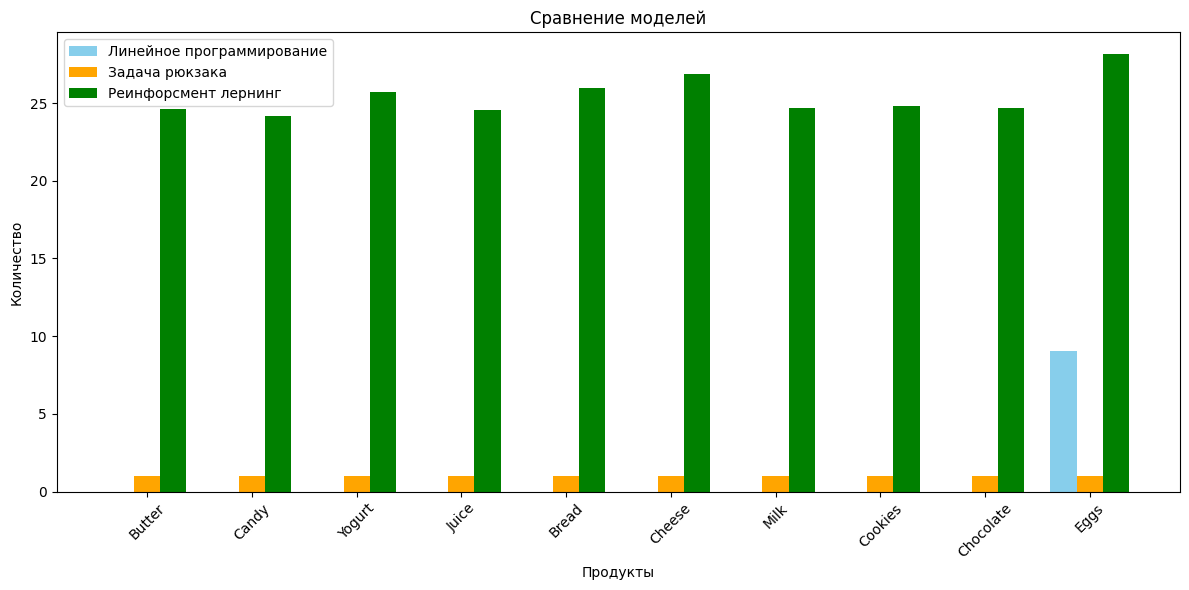

In [119]:
labels = products
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.25
# Линейное программирование
ax.bar(x - bar_width, optimal_lp, bar_width, label='Линейное программирование', color='skyblue')

# Рюкзак
ax.bar(x, optimal_knapsack_quantities, bar_width, label='Задача рюкзака', color='orange')

# Усиленное обучение
ax.bar(x + bar_width, optimal_rl_quantities, bar_width, label='Реинфорсмент лернинг', color='green')

ax.set_title('Сравнение моделей')
ax.set_xlabel('Продукты')
ax.set_ylabel('Количество')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

In [121]:
####Модель анализа региональных особенностей (5)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

shop_data_encoded = shop_data.copy()
label_encoders = {}
for col in ['Region', 'Seasonality', 'Category']:
    le = LabelEncoder()
    shop_data_encoded[col] = le.fit_transform(shop_data[col])
    label_encoders[col] = le

features = ['Region', 'Seasonality', 'Category', 'Discount', 'Stock_Level', 'Competitor_Price']
target = 'Quantity_Sold'

X = shop_data_encoded[features]
y = shop_data_encoded[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [122]:
# Decision Tree 
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X, y)
y_pred_dt = dt_model.predict(X)
mse_dt = mean_squared_error(y, y_pred_dt)

In [123]:
#Рандоооом фооорест
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)
y_pred_rf = rf_model.predict(X)
mse_rf = mean_squared_error(y, y_pred_rf)

In [124]:
#gradient boosting
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X, y)
y_pred_gb = gb_model.predict(X)
mse_gb = mean_squared_error(y, y_pred_gb)


In [125]:
#k means
kmeans = KMeans(n_clusters=4, random_state=42)
shop_data_encoded['Cluster'] = kmeans.fit_predict(X_scaled)

/var/folders/hk/tknfq7v96pqc7dqsct5qcdt40000gn/T/ipykernel_63229/2514480266.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mse_values, ax=axes[0], palette='viridis')


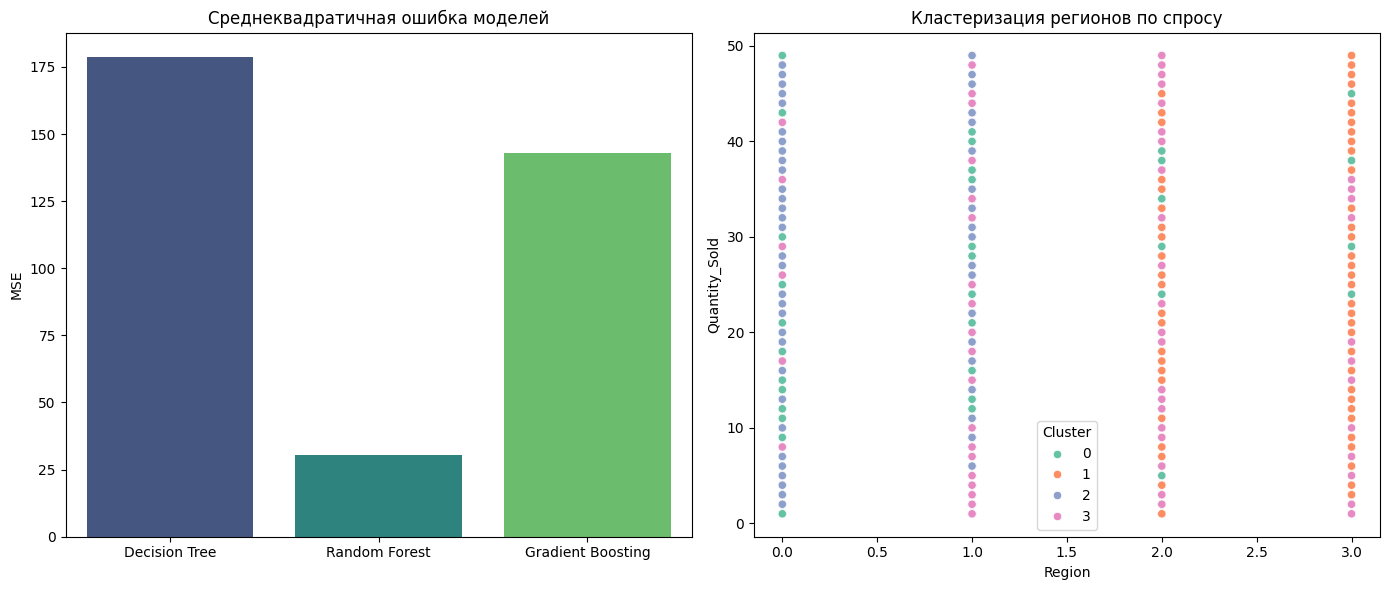

/var/folders/hk/tknfq7v96pqc7dqsct5qcdt40000gn/T/ipykernel_63229/2514480266.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features, y=feature_importances, palette='coolwarm')


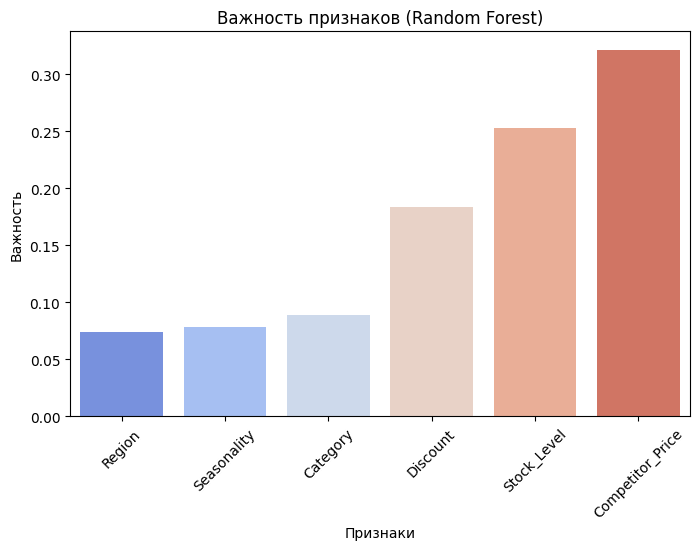

In [126]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
mse_values = [mse_dt, mse_rf, mse_gb]
sns.barplot(x=models, y=mse_values, ax=axes[0], palette='viridis')
axes[0].set_title('Среднеквадратичная ошибка моделей')
axes[0].set_ylabel('MSE')

#classification
sns.scatterplot(
    x='Region', y='Quantity_Sold', hue='Cluster', palette='Set2', data=shop_data_encoded, ax=axes[1]
)
axes[1].set_title('Кластеризация регионов по спросу')

plt.tight_layout()
plt.show()

feature_importances = rf_model.feature_importances_
plt.figure(figsize=(8, 5))
sns.barplot(x=features, y=feature_importances, palette='coolwarm')
plt.title('Важность признаков (Random Forest)')
plt.ylabel('Важность')
plt.xlabel('Признаки')
plt.xticks(rotation=45)
plt.show()

In [127]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [128]:
pip install itertools

ERROR: Could not find a version that satisfies the requirement itertools (from versions: none)
ERROR: No matching distribution found for itertools
Note: you may need to restart the kernel to use updated packages.


In [129]:
pip install itertools

ERROR: Could not find a version that satisfies the requirement itertools (from versions: none)
ERROR: No matching distribution found for itertools
Note: you may need to restart the kernel to use updated packages.


In [130]:
from itertools import product

In [134]:
import numpy as np
import gym
from gym import spaces
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Создание среды для RL
class ProcurementEnv(gym.Env):
    def __init__(self):
        super(ProcurementEnv, self).__init__()
        self.action_space = spaces.Discrete(3)  # 0: не закупать, 1: закупить немного, 2: закупить много
        self.observation_space = spaces.Box(low=0, high=100, shape=(3,), dtype=np.float32)  # Спрос, запасы, цена

    def reset(self):
        # Начальное состояние
        self.demand = np.random.randint(50, 150)
        self.stock = np.random.randint(0, 100)
        self.price = np.random.uniform(1, 3)
        return np.array([self.demand, self.stock, self.price])

    def step(self, action):
        # Принятие решения
        if action == 1:
            self.stock += 10
        elif action == 2:
            self.stock += 20

        # Обновление спроса и запасов
        self.demand = np.random.randint(50, 150)
        self.stock = max(0, self.stock - self.demand)
        self.price = np.random.uniform(1, 3)

        # Награда
        reward = -self.price * (action > 0) * 10  # Штраф за закупку
        if self.stock < 0:
            reward -= 100  # Штраф за дефицит

        # Проверка завершения эпизода
        done = False
        return np.array([self.demand, self.stock, self.price]), reward, done, {}

# Создание модели RL
model = Sequential([
    Dense(24, input_shape=(3,), activation='relu'),
    Dense(24, activation='relu'),
    Dense(3, activation='softmax')  # 3 действия
])
model.compile(optimizer=Adam(), loss='mse')

# Сохранение модели в формате .h5
model.save('reinforcement_learning_model.h5')

ModuleNotFoundError: No module named 'gym'

In [135]:
import numpy as np
import pickle
from google.colab import files

# Пример данных
num_products = 5
avg_demand = np.array([10, 20, 15, 25, 30])  # Спрос на продукты
avg_price = np.array([5.5, 10.2, 7.8, 12.3, 9.1])  # Цена закупки продуктов
budget = 50  # Бюджет

# Решение задачи о рюкзаке
def knapsack(values, weights, capacity):
    num_products = len(values)
    dp = np.zeros((num_products + 1, capacity + 1))

    # Заполнение таблицы dp
    for i in range(1, num_products + 1):
        for w in range(capacity + 1):
            if weights[i - 1] <= w:
                dp[i][w] = max(dp[i - 1][w], dp[i - 1][w - int(weights[i - 1])] + values[i - 1])
            else:
                dp[i][w] = dp[i - 1][w]

    # Восстановление решения
    optimal_knapsack = []
    w = capacity
    for i in range(num_products, 0, -1):
        if dp[i][w] != dp[i - 1][w]:
            optimal_knapsack.append(i - 1)
            w -= int(weights[i - 1])

    # Определение количества товаров для закупки
    optimal_knapsack_quantities = [1 if i in optimal_knapsack else 0 for i in range(num_products)]
    return optimal_knapsack_quantities

# Решение задачи
optimal_quantities = knapsack(avg_demand, avg_price, budget)

# Вывод результата
print("Оптимальные количества товаров для закупки:")
for i, quantity in enumerate(optimal_quantities):
    print(f"Товар {i + 1}: {quantity} единиц")

# Сохранение результата
with open('knapsack_model.pkl', 'wb') as f:
    pickle.dump(optimal_quantities, f)

# Скачивание файла
files.download('knapsack_model.pkl')

ModuleNotFoundError: No module named 'google.colab'